# Практичне завдання (pz6)

## Завдання
**18. Дослідження впливу затемнення на рівень освітленості в приміщенні.**
Потрібно порівняти рівень освітленості до і після застосування різних матеріалів для затемнення, таких як штори, жалюзі або плівки. Обробка даних включає аналіз змін рівня освітленості при різних типах затемнення.

## Суть завдання
За допомогою мобільного додатку **phyphox** були зібрані реальні дані з датчика освітленості (Ambient Light Sensor) мобільного телефону для різних сценаріїв затемнення у приміщенні. 
Телефон було розміщено на столі поблизу лампочки і вікна.

Експеримент проводився у 4 етапи:
1. **Відкриті штори і увімкнуте світло.**
2. **Закриті штори і увімкнуте світло.**
3. **Закриті штори і вимкнуте світло.**
4. **Відкриті штори і вимкнуте світло.**

**Апаратне забезпечення (згідно з даними `device.csv`)**:
- **Модель телефону**: OnePlus CPH2447
- **Сенсор**: `tcs3701 Oplus Ambient Light Sensor Non-wakeup` (Виробник: oplus)
- **Характеристики сенсора**: діапазон вимірювання до 65535.0, роздільна здатність 0.1, енергоспоживання 0.08 мА.

### Додаток для збору даних
<img src="app_icon.jpg" alt="Arduino Science Journal Icon" width="200"/>

## Опис результатів
У результаті збору даних було отримано набір показників освітленості (у люксах), що зберігаються у файлі `Light.csv`. Аналізуючи дані, можна чітко розпізнати вплив кожного етапу:

1. Максимальний рівень освітлення присутній при відкритих шторах та увімкненому джерелі світла.
2. Після закриття штор рівень люксів значно знижується, що дозволяє кількісно оцінити ступінь затемнення (світлопроникність) матеріалу штор.
3. Повне вимкнення світла при закритих шторах опускає показники майже до мінімального фонового рівня освітленості кімнати.
4. Повернення світла знову підіймає показники на рівень, відповідний 2-му етапу.

Графік, згенерований безпосередньо у додатку під час фіксування даних:

![Графік освітлености](graphic.jpg)

## Приклади використання
Подібний підхід до збору та аналізу даних має широке практичне використання:
- **Оцінка ефективності сонцезахисних систем:** порівняння різних матеріалів штор, жалюзі або тонувальних плівок за відсотком блокування світла.
- **Проектування систем розумного будинку (Smart Home):** збір даних для навчання алгоритмів, які автоматично регулюють освітлення залежно від природного світла та положення штор для економії електроенергії.
- **Ергономіка та охорона праці:** перевірка відповідності рівня освітленості на робочому місці (на столі) санітарним нормам у різний час доби.

## Код для аналізу
Нижче наведено код для завантаження, обробки та візуалізації зібраних даних з детальним аналізом конкретних часових точок (2с, 5с, 11с, 16с) для визначення ефективності різних джерел світла та засобів затемнення.

Дані успішно завантажено!

================ АНАЛІЗ ОСВІТЛЕНОСТІ ================
1. Відкриті штори + увімкнена лампа (2 сек):  60 Люкс
2. Закриті штори + увімкнена лампа  (5 сек):  54 Люкс
3. Закриті штори + вимкнена лампа   (11 сек): 4 Люкс
4. Відкриті штори + вимкнена лампа  (16 сек): 11 Люкс

================ ВИСНОВКИ (Ефективність) ================
-> Ефективність лампочки: Лампа додає яскравості на 50 Люкс.
-> Ефективність штор (при денному світлі): З 11 Люкс природного світла штори блокують 7 Люкс.
   Тобто ефективність матеріалу штор становить 63.6%.
-> Ефективність штор (зі змішаним світлом): Штори блокують 6 Люкс.


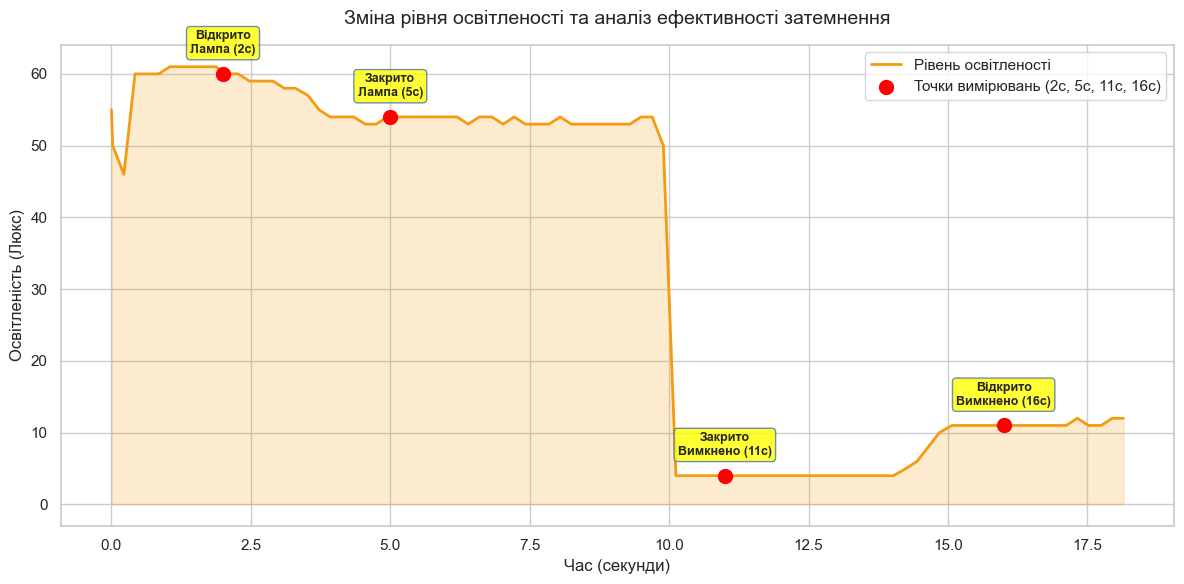

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних з файлу .csv
try:
    df_light = pd.read_csv('Light.csv')
    print("Дані успішно завантажено!")
except Exception as e:
    print(f"Помилка зчитування файлу CSV:\n{e}")
    df_light = pd.DataFrame()

if not df_light.empty:
    # Визначимо колонки динамічно (перша колонка - час, друга - значення рівня світла)
    if len(df_light.columns) >= 2:
        time_col = df_light.columns[0]
        lux_col = df_light.columns[1]
        
        # --- Вилучення даних у заданих точках часу (найближчі значення) ---
        t1, t2, t3, t4 = 2.0, 5.0, 11.0, 16.0
        
        val_2s = df_light.loc[(df_light[time_col] - t1).abs().idxmin(), lux_col]
        val_5s = df_light.loc[(df_light[time_col] - t2).abs().idxmin(), lux_col]
        val_11s = df_light.loc[(df_light[time_col] - t3).abs().idxmin(), lux_col]
        val_16s = df_light.loc[(df_light[time_col] - t4).abs().idxmin(), lux_col]
        
        print("\n================ АНАЛІЗ ОСВІТЛЕНОСТІ ================")
        print(f"1. Відкриті штори + увімкнена лампа (2 сек):  {val_2s} Люкс")
        print(f"2. Закриті штори + увімкнена лампа  (5 сек):  {val_5s} Люкс")
        print(f"3. Закриті штори + вимкнена лампа   (11 сек): {val_11s} Люкс")
        print(f"4. Відкриті штори + вимкнена лампа  (16 сек): {val_16s} Люкс")
        print("=====================================================")
        
        # --- Обчислення ефективності ---
        # Ефективність лампочки = Різниця між (Закриті+лампа) та (Закриті+вимкнена)
        lamp_eff = val_5s - val_11s
        
        # Ефективність затемнення шторами = Різниця між відкритими та закритими шторами
        curtain_eff_daylight = val_16s - val_11s
        curtain_eff_mixed = val_2s - val_5s
        
        # Відсоток ефективності штор відносно природного світла
        percent_eff = (curtain_eff_daylight / val_16s) * 100 if val_16s > 0 else 0
        
        print("\n================ ВИСНОВКИ (Ефективність) ================")
        print(f"-> Ефективність лампочки: Лампа додає яскравості на {lamp_eff} Люкс.")
        print(f"-> Ефективність штор (при денному світлі): З {val_16s} Люкс природного світла штори блокують {curtain_eff_daylight} Люкс.")
        print(f"   Тобто ефективність матеріалу штор становить {percent_eff:.1f}%.")
        print(f"-> Ефективність штор (зі змішаним світлом): Штори блокують {curtain_eff_mixed} Люкс.")
        print("=========================================================")
        
        # Побудова графіка з маркерами точок аналізу
        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(12, 6))
        
        plt.plot(df_light[time_col], df_light[lux_col], color='#f39c12', linewidth=2, label='Рівень освітленості')
        
        # Додавання маркерів на графік
        marker_times = [t1, t2, t3, t4]
        marker_vals = [val_2s, val_5s, val_11s, val_16s]
        marker_labels = ['Відкрито\nЛампа (2с)', 'Закрито\nЛампа (5с)', 'Закрито\nВимкнено (11с)', 'Відкрито\nВимкнено (16с)']
        
        plt.scatter(marker_times, marker_vals, color='red', zorder=5, s=100, label='Точки вимірювань (2с, 5с, 11с, 16с)')
        for i, txt in enumerate(marker_labels):
            plt.annotate(txt, (marker_times[i], marker_vals[i]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.8))
        
        plt.title('Зміна рівня освітленості та аналіз ефективності затемнення', fontsize=14, pad=15)
        plt.xlabel('Час (секунди)', fontsize=12)
        plt.ylabel('Освітленість (Люкс)', fontsize=12)
        
        plt.fill_between(df_light[time_col], df_light[lux_col], color='#f39c12', alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Датасет містить менш ніж 2 колонки. Візуалізація неможлива.")
else:
    print("Не вдалося завантажити дані.")